In [2]:
! pip install --upgrade xarray zarr gcsfs cftime nc-time-axis

In [3]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import zarr
import gcsfs

xr.set_options(display_style='html')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [4]:
plt.rcParams['figure.figsize'] = 12, 6

In [5]:
df = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')
df.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,ps,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
1,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rsds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
2,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
3,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
4,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,psl,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706


In [6]:
carbon_keywords = [
    "carbon",
    "co2",
    "cLand",
    "cSoil",
    "co2mass"
]

for keyword in carbon_keywords:
    matches = df[df["variable_id"].str.contains(keyword, case=False, na=False)]
    
    print(f"\n--- {keyword} ---")
    print(matches["variable_id"].unique()[:20])


--- carbon ---
[]

--- co2 ---
['co2mass' 'spco2' 'fgco2' 'dpco2' 'co23D' 'co2s' 'co2'
 'netAtmosLandCO2Flux' 'spco2abio' 'spco2nat' 'fgco2abio' 'fgco2nat'
 'dpco2nat' 'dpco2abio' 'fg14co2abio' 'fco2nat' 'fco2antt']

--- cLand ---
['cLand']

--- cSoil ---
['cSoil' 'cSoilLut' 'cSoilSlow' 'cSoilFast' 'cSoilMedium']

--- co2mass ---
['co2mass']


In [7]:
variables = ["cLand", "cSoil", "co2mass"]

In [8]:
df_carbon = df[
    df["variable_id"].isin(["cLand", "cSoil", "co2mass"])
]

df_carbon.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
686,CMIP,CNRM-CERFACS,CNRM-CM6-1,1pctCO2,r1i1p1f2,Amon,co2mass,gr,gs://cmip6/CMIP6/CMIP/CNRM-CERFACS/CNRM-CM6-1/...,NaN,20180626
1296,CMIP,NOAA-GFDL,GFDL-ESM4,esm-piControl,r1i1p1f1,Amon,co2mass,gn,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/esm-...,NaN,20180701
1465,CMIP,NOAA-GFDL,GFDL-ESM4,abrupt-4xCO2,r1i1p1f1,Emon,cLand,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/abru...,NaN,20180701
2116,CMIP,NOAA-GFDL,GFDL-ESM4,1pctCO2,r1i1p1f1,Emon,cLand,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/1pct...,NaN,20180701
2118,CMIP,NOAA-GFDL,GFDL-ESM4,1pctCO2,r1i1p1f1,Emon,cSoil,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/1pct...,NaN,20180701


In [9]:
df_carbon["experiment_id"].value_counts().head(20)

experiment_id
historical             395
ssp370                 181
hist-nat                72
1pctCO2                 70
piControl               40
abrupt-4xCO2            31
ssp245                  27
ssp126                  22
ssp585                  22
1pctCO2-bgc             21
1pctCO2-rad             17
land-hist                9
esm-hist                 8
ssp245-cov-strgreen      7
ssp245-covid             7
ssp245-cov-modgreen      6
ssp245-cov-fossil        6
ssp460                   5
ssp119                   5
esm-pi-CO2pulse          4
Name: count, dtype: int64

In [11]:
df_carbon = df_carbon[
    df_carbon["experiment_id"].isin([
        "historical",
        "ssp245",
        "ssp585"
    ])
]

df_carbon[[
    "variable_id",
    "experiment_id",
    "source_id",
    "table_id"
]].head(30)

,variable_id,experiment_id,source_id,table_id
2317,co2mass,ssp245,GFDL-CM4,Amon
2460,co2mass,ssp585,GFDL-CM4,Amon
6254,co2mass,historical,GFDL-CM4,Amon
15360,co2mass,ssp245,GFDL-ESM4,Amon
18976,co2mass,ssp585,GFDL-ESM4,Amon
22166,co2mass,historical,IPSL-CM6A-LR,Amon
22177,cSoil,historical,IPSL-CM6A-LR,Emon
22380,cSoil,historical,IPSL-CM6A-LR,Emon
22394,cSoil,historical,IPSL-CM6A-LR,Eyr
22461,cSoil,historical,IPSL-CM6A-LR,Eyr


In [12]:
df_co2 = df_carbon[
    df_carbon["variable_id"] == "co2mass"
]

df_co2[[
    "source_id",
    "experiment_id",
    "member_id",
    "table_id",
    "zstore"
]].head(20)

,source_id,experiment_id,member_id,table_id,zstore
2317,GFDL-CM4,ssp245,r1i1p1f1,Amon,gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-CM...
2460,GFDL-CM4,ssp585,r1i1p1f1,Amon,gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-CM...
6254,GFDL-CM4,historical,r1i1p1f1,Amon,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/histo...
15360,GFDL-ESM4,ssp245,r1i1p1f1,Amon,gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-ES...
18976,GFDL-ESM4,ssp585,r1i1p1f1,Amon,gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-ES...
22166,IPSL-CM6A-LR,historical,r9i1p1f1,Amon,gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/histor...
23530,IPSL-CM6A-LR,historical,r6i1p1f1,Amon,gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/histor...
28063,IPSL-CM6A-LR,historical,r16i1p1f1,Amon,gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/histor...
29976,IPSL-CM6A-LR,historical,r28i1p1f1,Amon,gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/histor...
37683,CNRM-CM6-1,historical,r1i1p1f2,Amon,gs://cmip6/CMIP6/CMIP/CNRM-CERFACS/CNRM-CM6-1/...


In [13]:
df_co2_model = df_co2[
    df_co2["source_id"] == "GFDL-CM4"
]

df_co2_model[[
    "source_id",
    "experiment_id",
    "member_id",
    "table_id",
    "zstore"
]]

,source_id,experiment_id,member_id,table_id,zstore
2317,GFDL-CM4,ssp245,r1i1p1f1,Amon,gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-CM...
2460,GFDL-CM4,ssp585,r1i1p1f1,Amon,gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-CM...
6254,GFDL-CM4,historical,r1i1p1f1,Amon,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/histo...


In [14]:
co2_datasets = {}

for exp in ["historical", "ssp245", "ssp585"]:
    row = df_co2_model[df_co2_model["experiment_id"] == exp].iloc[0]
    zstore = row["zstore"]

    ds_exp = xr.open_zarr(
        gcsfs.GCSMap(zstore),
        consolidated=True
    )

    co2_datasets[exp] = ds_exp
    print(exp, ds_exp)

historical <xarray.Dataset> Size: 55kB
Dimensions:    (time: 1980, bnds: 2)
Coordinates:
  * time       (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * bnds       (bnds) float64 16B 1.0 2.0
    time_bnds  (time, bnds) object 32kB ...
Data variables:
    co2mass    (time) float32 8kB ...
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.0 UGRID-1.0
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  36500.0
    comment:                <null ref>
    ...                     ...
    table_id:               Amon
    title:                  NOAA GFDL GFDL-CM4 model output prepared for CMIP...
    tracking_id:            hdl:21.14100/5be855d4-157c-4bd0-b895-09aadad0882d...
    variable_id:            co2mass
    variant_info:           N/A
    variant_label:          r1i1p1f1
ssp245 <xarray.Dataset> Size: 29kB
Dimensions:    (time: 1032, bnds: 2)
Coordinates:
  * time       (time) obj

In [15]:
co2_datasets["historical"]["co2mass"]

<xarray.DataArray 'co2mass' (time: 1980)> Size: 8kB
[1980 values with dtype=float32]
Coordinates:
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
Attributes:
    cell_methods:   area: time: mean
    long_name:      Total Atmospheric Mass of CO2
    original_name:  co2mass
    standard_name:  atmosphere_mass_of_carbon_dioxide
    units:          kg

In [36]:
co2_frames = []

for scenario, ds_exp in co2_datasets.items():

    co2 = ds_exp["co2mass"]

    yearly = co2.groupby("time.year").mean("time")

    temp_df = yearly.to_dataframe(name="co2mass").reset_index()

    temp_df["scenario"] = scenario

    co2_frames.append(temp_df)

co2_df = pd.concat(co2_frames, ignore_index=True)

co2_df = co2_df[[
    "year",
    "scenario",
    "co2mass"
]]

co2_df.head()

,year,scenario,co2mass
0,1850,historical,2.214735e+15
1,1851,historical,2.215836e+15
2,1852,historical,2.216960e+15
3,1853,historical,2.217980e+15
4,1854,historical,2.218872e+15


In [37]:
co2_df.to_csv(
    "../data/processed/co2_timeseries.csv",
    index=False
)

In [17]:
df_cland = df_carbon[
    df_carbon["variable_id"] == "cLand"
]

df_cland[[
    "source_id",
    "experiment_id",
    "member_id",
    "table_id"
]].head(20)

,source_id,experiment_id,member_id,table_id
244666,GFDL-ESM4,historical,r1i1p1f1,Emon


In [18]:
row = df_cland.iloc[0]
zstore = row["zstore"]

ds_cland = xr.open_zarr(
    gcsfs.GCSMap(zstore),
    consolidated=True
)

ds_cland

<xarray.Dataset> Size: 411MB
Dimensions:    (time: 1980, lat: 180, lon: 288, bnds: 2)
Coordinates:
  * time       (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
  * bnds       (bnds) float64 16B 1.0 2.0
    lat_bnds   (lat, bnds) float64 3kB ...
    lon_bnds   (lon, bnds) float64 5kB ...
    time_bnds  (time, bnds) object 32kB ...
Data variables:
    cLand      (time, lat, lon) float32 411MB ...
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.0 UGRID-1.0
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  36500.0
    comment:                <null ref>
    ...                     ...
    table_id:               Emon
    title:                  NOAA GFDL GFDL-ESM4 model output prepared for CMI...
    tracking_id:            hdl:21.14100/210cd3f1-ec15-416d-a7b6-7657b5405c59...
    variable_id:            cLand
    variant_info:           N/A
    variant_label:          r1i1p1f1

In [19]:
ds_cland["cLand"]

<xarray.DataArray 'cLand' (time: 1980, lat: 180, lon: 288)> Size: 411MB
[102643200 values with dtype=float32]
Coordinates:
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
Attributes:
    cell_measures:    area: areacella
    cell_methods:     area: mean where land time: mean
    comment:          land_area = areacella * sftlf * 0.01
    interp_method:    conserve_order1
    long_name:        Total Carbon in All Terrestrial Carbon Pools
    ocean_fillvalue:  0.0
    original_name:    cLand
    standard_name:    mass_content_of_carbon_in_vegetation_and_litter_and_soi...
    units:            kg m-2

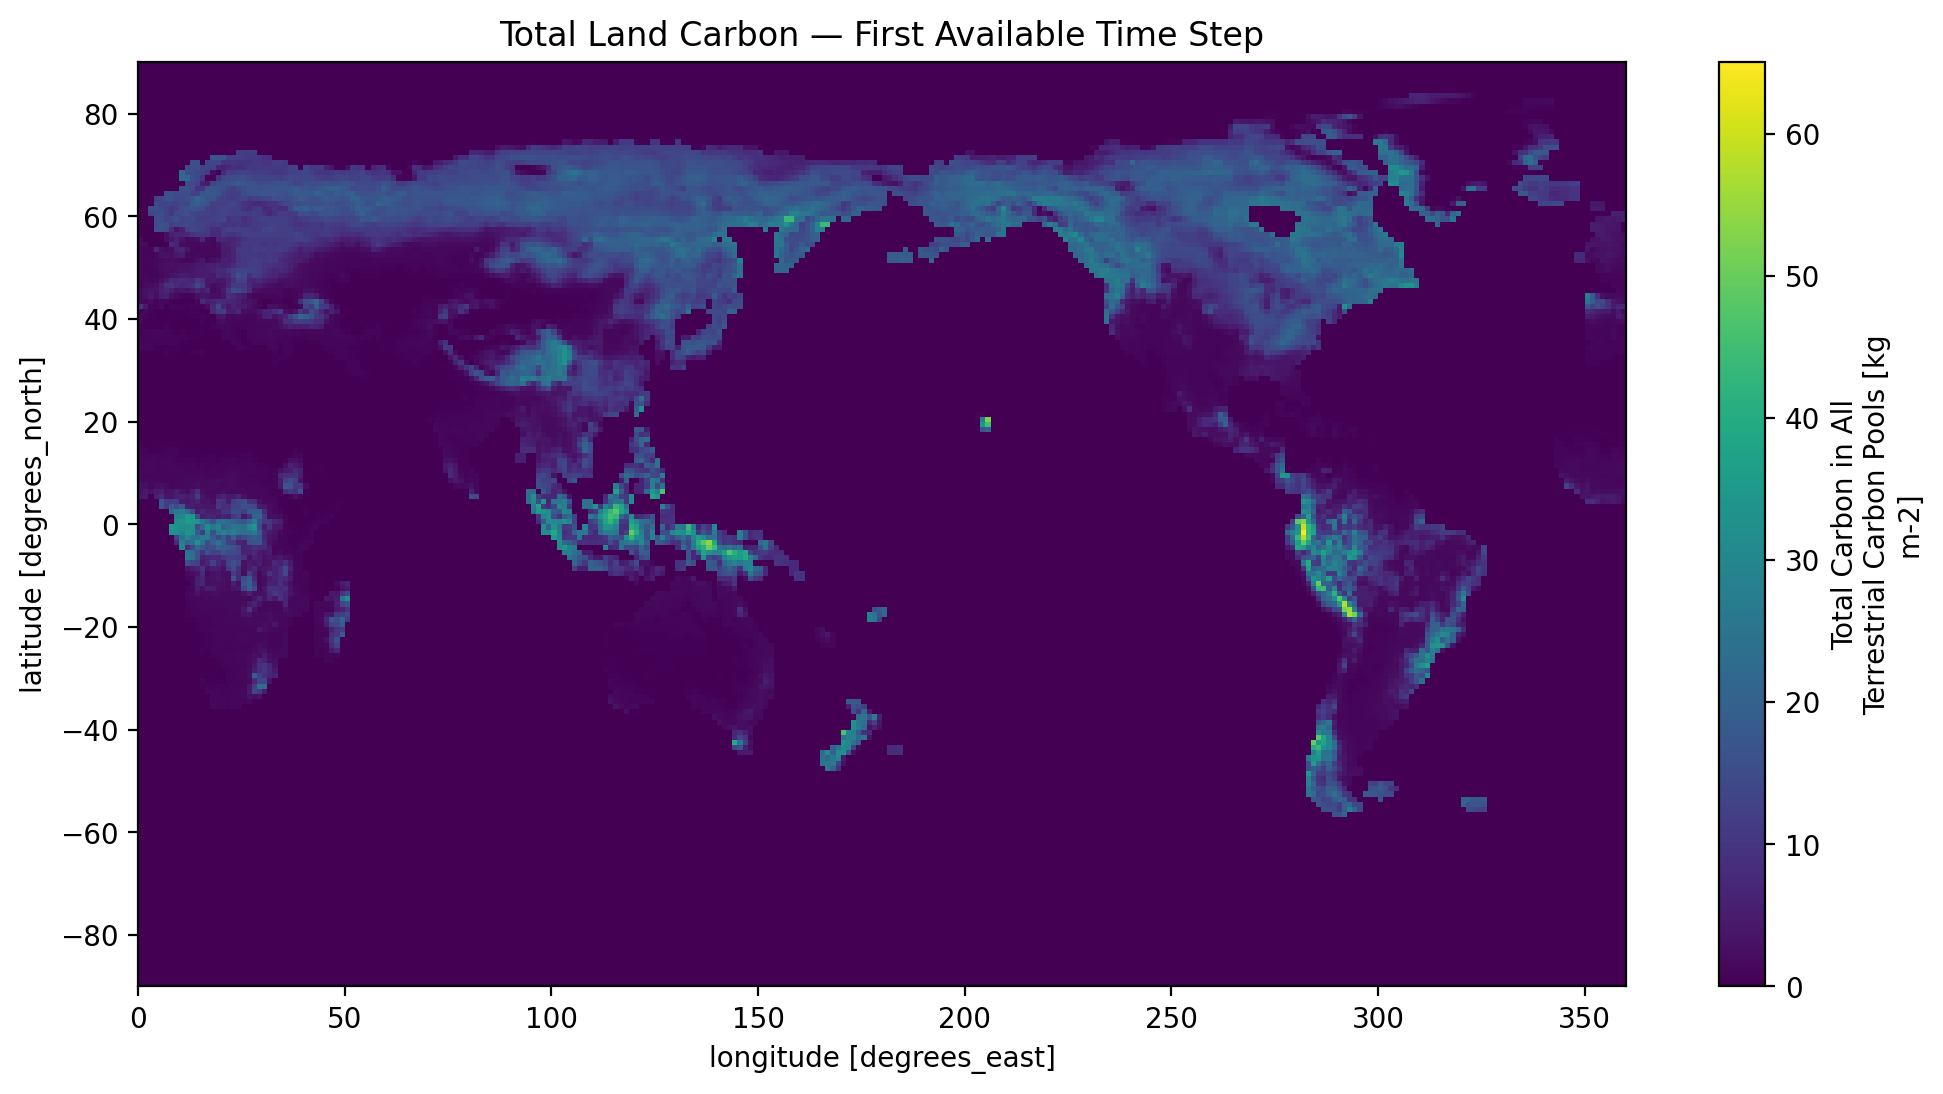

In [20]:
ds_cland["cLand"].isel(time=0).plot()
plt.title("Total Land Carbon — First Available Time Step")
plt.show()

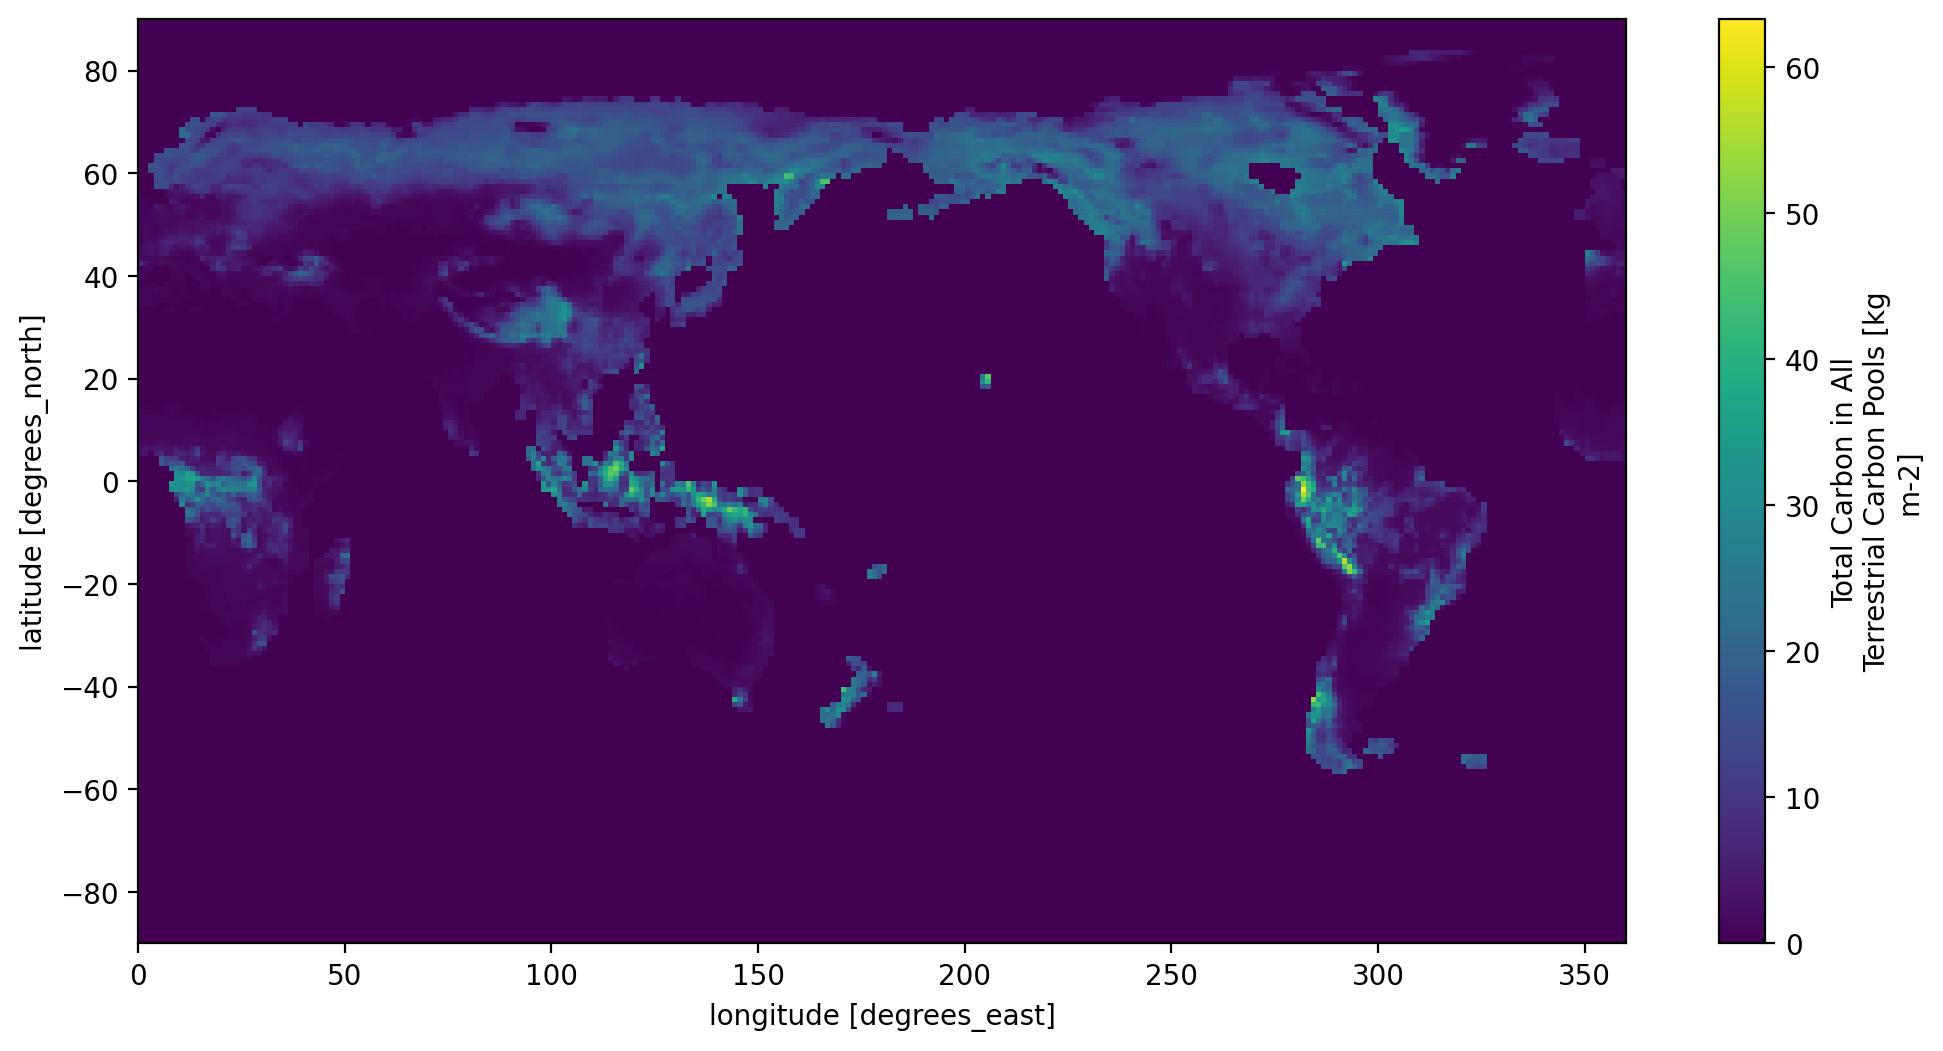

In [21]:
ds_cland["cLand"].mean(dim="time").plot()

In [34]:
cland_mean = ds_cland["cLand"].mean(dim="time")

cland_df = cland_mean.to_dataframe(name="cLand").reset_index()

cland_df = cland_df.rename(columns={
    "lat": "latitude",
    "lon": "longitude"
})

cland_df = cland_df.dropna()

cland_df.head()

,latitude,longitude,cLand
0,-89.5,0.625,0.001302
1,-89.5,1.875,0.001302
2,-89.5,3.125,0.001302
3,-89.5,4.375,0.001302
4,-89.5,5.625,0.001302


In [35]:
cland_df.to_csv(
    "../data/processed/cland_mean.csv",
    index=False
)